## **t-SNE**

- Non-Linear
- Unsupervised
- Manfold Learning Method


Mostly used for visualization and because of the non-deterministic nature of it we don't use this algorithm in the training process (although we can make this algorithm deterministic using random_state parameter).

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

In [30]:
data = load_wine()

X, y = data['data'], data['target']
wine = pd.DataFrame(data=X, columns=data['feature_names'])
wine['target'] = y

wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [31]:
# scaling the data, scaling is important in dimenstionality reduction techniques
X_scaled = StandardScaler().fit_transform(X)

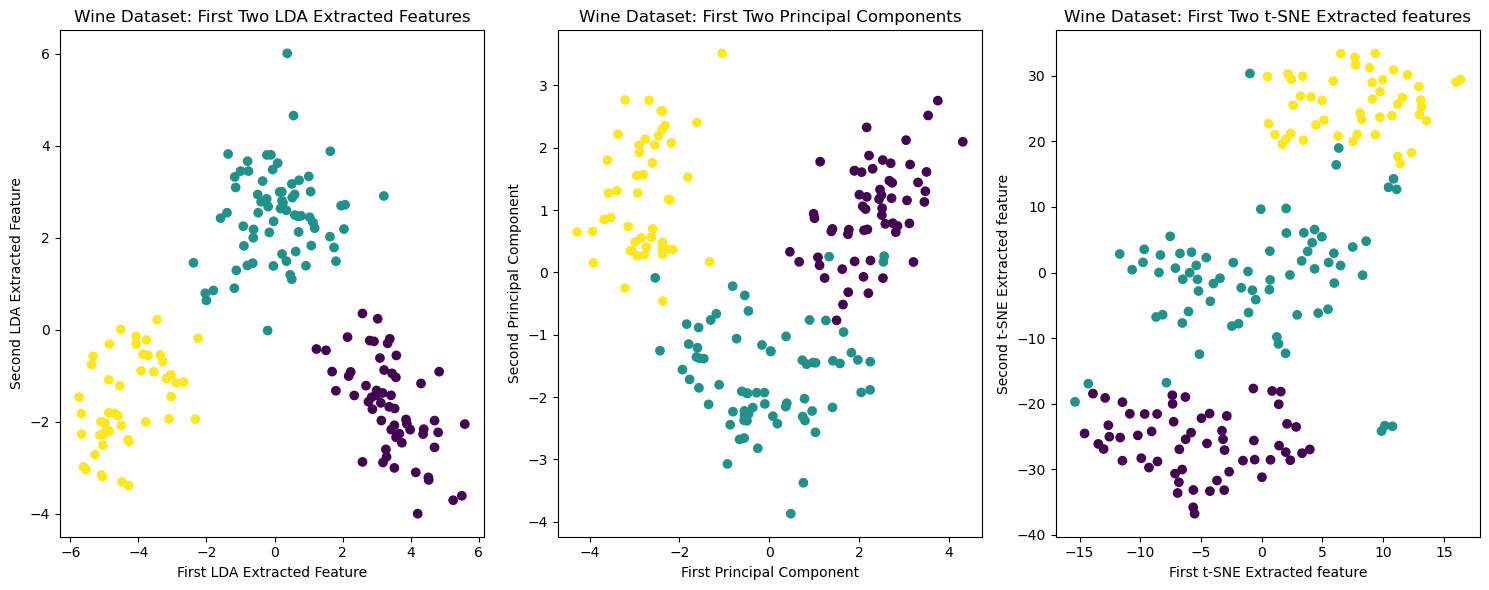

In [63]:
# transformations
tsne = TSNE(n_components=2, perplexity=15)
X_tsne = tsne.fit_transform(X_scaled)

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# visualizing data
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].scatter(X_lda[:, 0], X_lda[:, 1], c=y)
axs[0].set(
    title="Wine Dataset: First Two LDA Extracted Features",
    xlabel="First LDA Extracted Feature",
    ylabel="Second LDA Extracted Feature"
)

axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y)
axs[1].set(
    title="Wine Dataset: First Two Principal Components",
    xlabel="First Principal Component",
    ylabel="Second Principal Component"
)

axs[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
axs[2].set(
    title="Wine Dataset: First Two t-SNE Extracted features",
    xlabel="First t-SNE Extracted feature",
    ylabel="Second t-SNE Extracted feature"
)

plt.tight_layout()

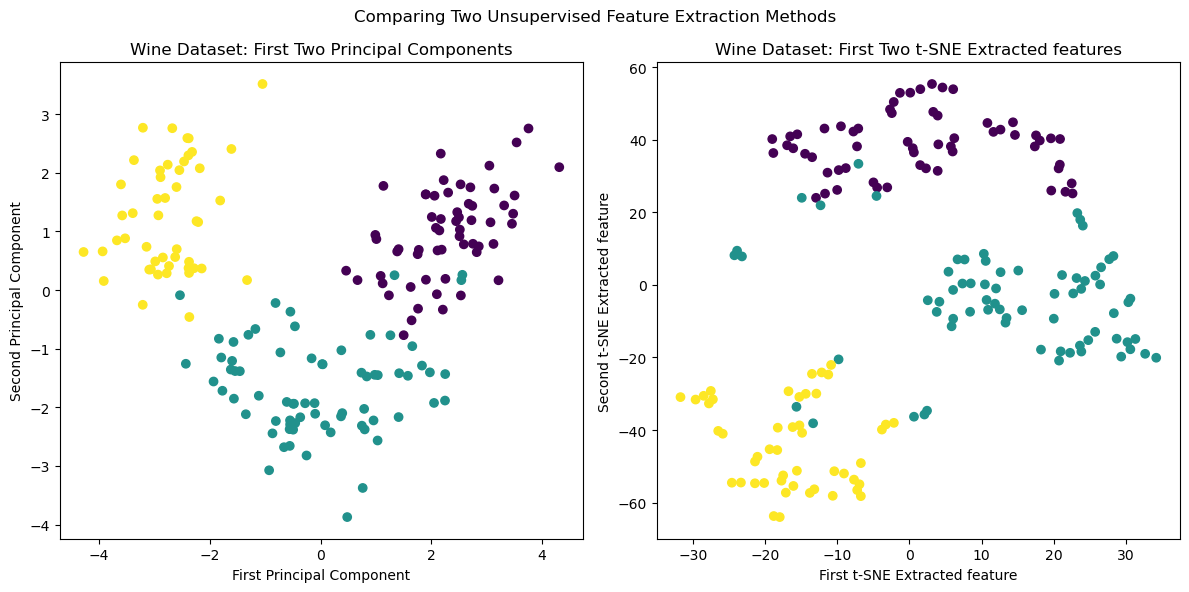

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.suptitle("Comparing Two Unsupervised Feature Extraction Methods")

axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y)
axs[0].set(
    title="Wine Dataset: First Two Principal Components",
    xlabel="First Principal Component",
    ylabel="Second Principal Component"
)

axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
axs[1].set(
    title="Wine Dataset: First Two t-SNE Extracted features",
    xlabel="First t-SNE Extracted feature",
    ylabel="Second t-SNE Extracted feature"
)

plt.tight_layout()

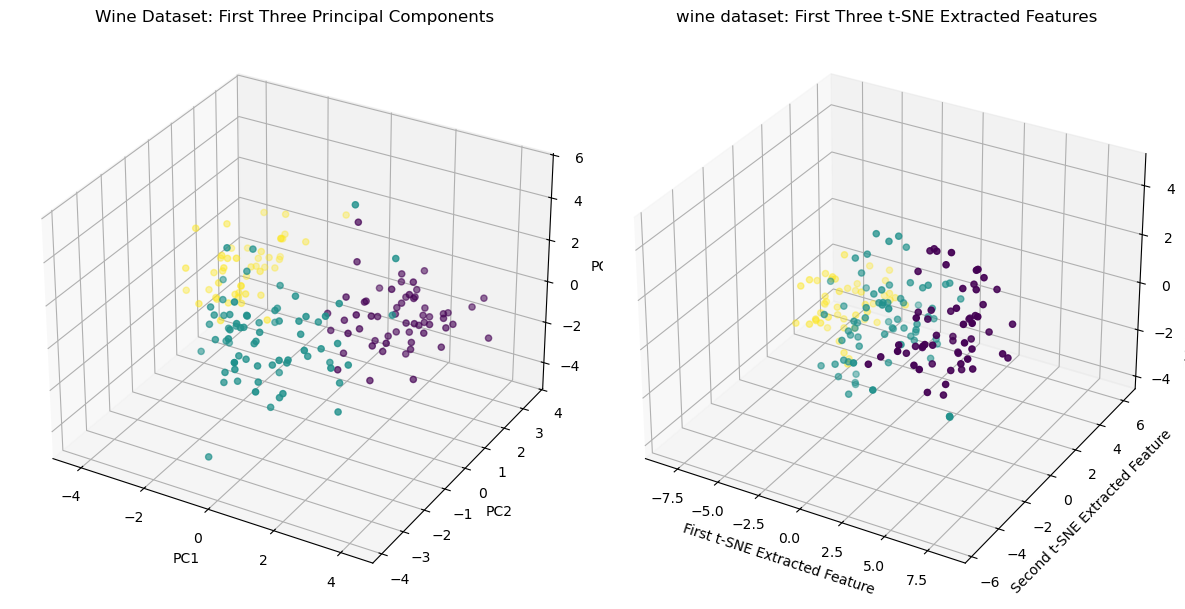

In [35]:
X_tsne_3d = TSNE(n_components=3).fit_transform(X_scaled)

plt.figure(figsize=(12, 6))

ax1 = plt.subplot(121, projection = "3d")
ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y)
ax1.set(
    title="wine dataset: first three principal components".title(),
    xlabel="PC1",
    ylabel="PC2",
    zlabel="PC3"
)

ax2 = plt.subplot(122, projection = "3d")
ax2.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c=y)
ax2.set(
    title="wine dataset: First Three t-SNE Extracted Features",
    xlabel="First t-SNE Extracted Feature",
    ylabel="Second t-SNE Extracted Feature",
    zlabel="Third t-SNE Extracted Feature"
)

plt.tight_layout()

## Using Hybrid Approach:

We try using PCA and t-SNE together in this way that we run t-SNE algorithm on the principal components and compare the results with PCA and t-SNE method.

In [36]:
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [37]:
wine.shape

(178, 14)

In [38]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# t-SNE with PCA
pca_tsne_2d = TSNE(n_components=2)
X_pca_tsne_2d = pca_tsne_2d.fit_transform(X_pca)

pca_tsne_3d = TSNE(n_components=3)
X_pca_tsne_3d = pca_tsne_3d.fit_transform(X_pca)

# t-SNE without PCA
tsne_2d = TSNE(n_components=2)
X_tsne_2d = tsne_2d.fit_transform(X_pca)

tsne_3d = TSNE(n_components=3)
X_tsne_3d = tsne_3d.fit_transform(X_pca)

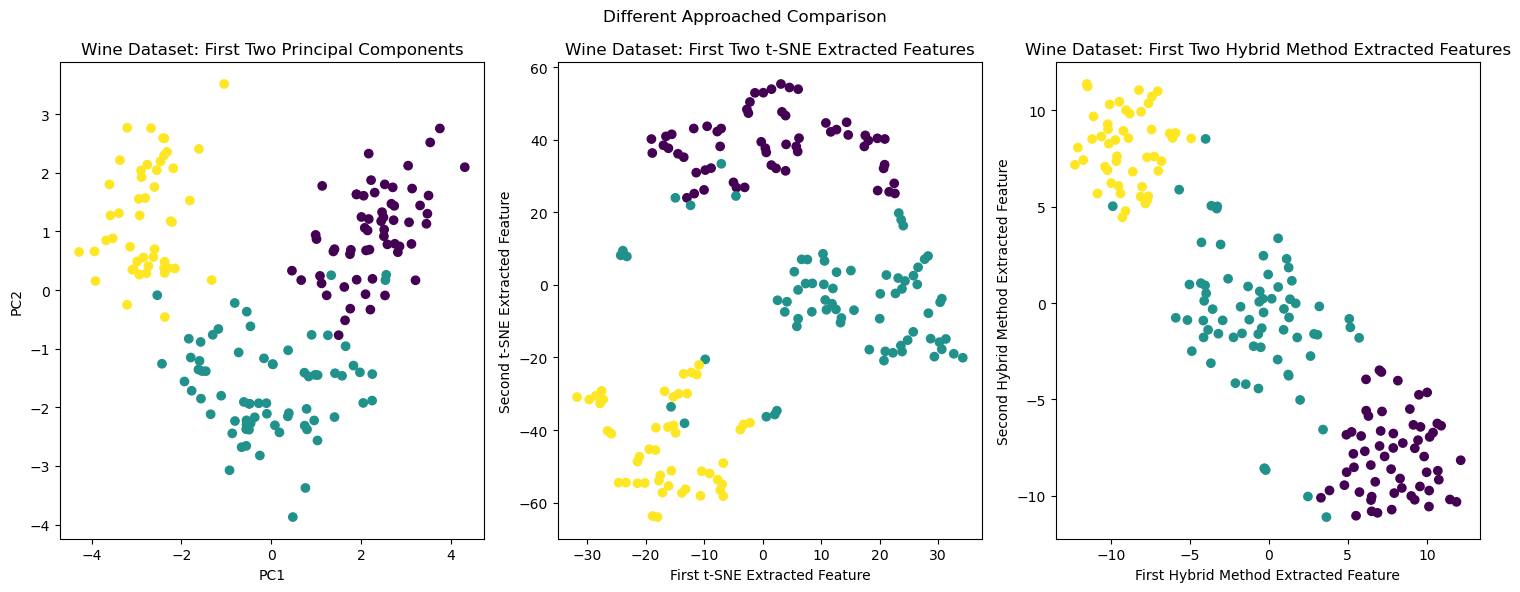

In [44]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
plt.suptitle("Different Approached Comparison")

ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
ax1.set(
    title="Wine Dataset: First Two Principal Components",
    xlabel="PC1",
    ylabel="PC2"
)

ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
ax2.set(
    title="Wine Dataset: First Two t-SNE Extracted Features",
    xlabel="First t-SNE Extracted Feature",
    ylabel="Second t-SNE Extracted Feature"
)

ax3.scatter(X_pca_tsne_2d[:, 0], X_pca_tsne_2d[:, 1], c=y)
ax3.set(
    title="Wine Dataset: First Two Hybrid Method Extracted Features",
    xlabel="First Hybrid Method Extracted Feature",
    ylabel="Second Hybrid Method Extracted Feature"
)

plt.tight_layout()

We can see that using a hybrid method of the combination of PCA and t-SNE we can gain better results.

Next we compare using just t-SNE, using just LDA, and a combination of them:

In [45]:
# t-SNE with LDA
lda_tsne = TSNE(n_components=2)
X_lda_tsne = lda_tsne.fit_transform(X_lda)

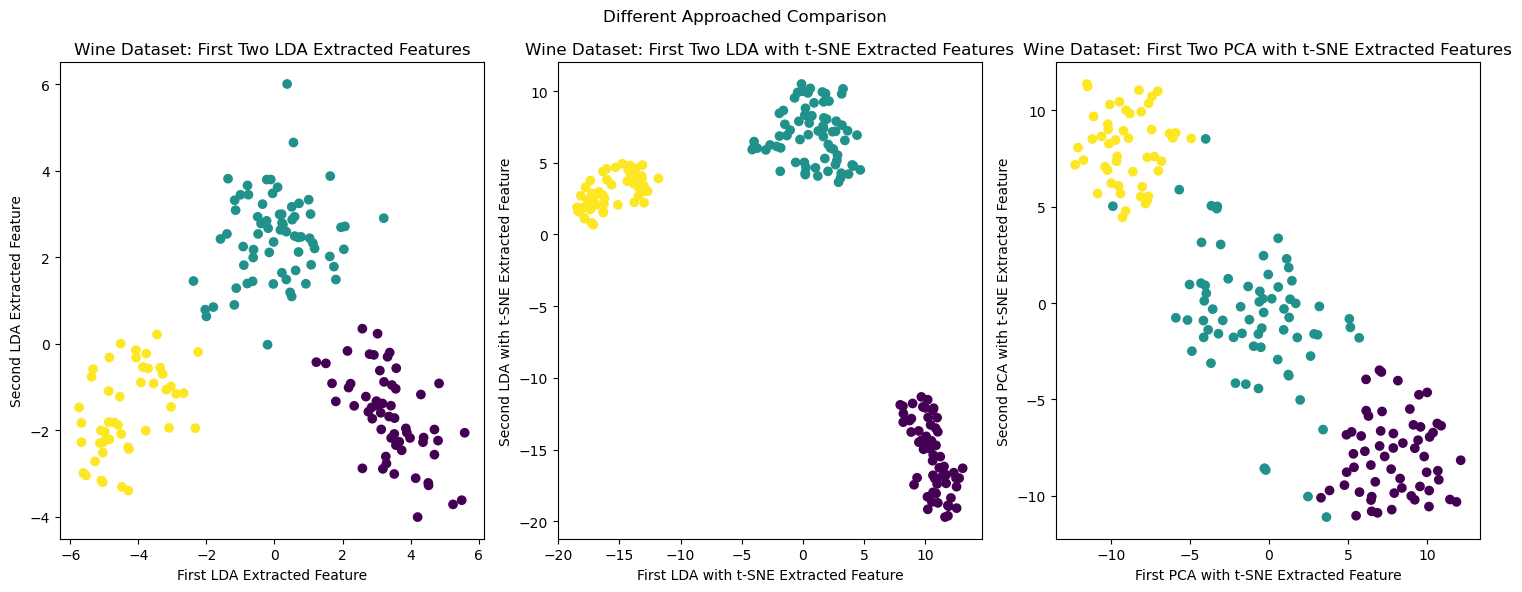

In [48]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
plt.suptitle("Different Approached Comparison")

ax1.scatter(X_lda[:, 0], X_lda[:, 1], c=y)
ax1.set(
    title="Wine Dataset: First Two LDA Extracted Features",
    xlabel="First LDA Extracted Feature",
    ylabel="Second LDA Extracted Feature"
)

ax2.scatter(X_lda_tsne[:, 0], X_lda_tsne[:, 1], c=y)
ax2.set(
    title="Wine Dataset: First Two LDA with t-SNE Extracted Features",
    xlabel="First LDA with t-SNE Extracted Feature",
    ylabel="Second LDA with t-SNE Extracted Feature"
)

ax3.scatter(X_pca_tsne_2d[:, 0], X_pca_tsne_2d[:, 1], c=y)
ax3.set(
    title="Wine Dataset: First Two PCA with t-SNE Extracted Features",
    xlabel="First PCA with t-SNE Extracted Feature",
    ylabel="Second PCA with t-SNE Extracted Feature"
)

plt.tight_layout()

We can see using a combination of approaches in general can improve the results (should always validated in the real-world projects). We can see a hybrid approach in feature extraction using both LDA and t-SNE algorithm results in clusters that are very seperate from each other. LDA is a supervised algorithm and include the knowledge about the classes so results in better seperation between clusters like its goal, so we see that using this hybrid approach is better that PCA with t-SNE for this dataset and results in better clusters as we can see in the visualizations above.

> Note: It's always important to tune the `perplexity` parameter in t-SNE to get better visualizations.